In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')
adata.obs['progression'] = adata.obs['patient'].map({
 'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'})

In [3]:
adata

AnnData object with n_obs × n_vars = 66813 × 36601
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_

In [4]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

In [5]:
b_clonotypes = adata[adata.obs['timepoint'] == 'B'].obs['clonotype_patient'].tolist()
f1_clonotypes = adata[adata.obs['timepoint'] == 'F1'].obs['clonotype_patient'].tolist()
f2_clonotypes = adata[adata.obs['timepoint'] == 'F2'].obs['clonotype_patient'].tolist()

In [6]:
blood = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/blood_tcr_analysis/blood_CDR3_beta.csv')

In [7]:
tumor = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/blood_tcr_analysis/single_cell_sequences_wo_t_naive_early_memory.csv')

# Expansion/Contraction

In [8]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

## B - F1

In [9]:
adata_bf1 = adata[adata.obs['timepoint'].isin(['B','F1'])]

In [10]:
clonotype_counts_b = adata_bf1[adata_bf1.obs['timepoint'] == 'B'].obs['clonotype_patient'].value_counts()
clonotype_counts_f1 = adata_bf1[adata_bf1.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()

In [11]:
clonotype_counts_b

11840_E25    83
10475_E15    77
9895_E30     70
3931_E31     60
18991_E20    59
             ..
17170_E18     1
17171_E18     1
17173_E18     1
17174_E18     1
9101_E23      1
Name: clonotype_patient, Length: 14052, dtype: int64

In [12]:
clonotype_counts_bf1 = pd.concat([clonotype_counts_b,
                                  clonotype_counts_f1],axis=1)
clonotype_counts_bf1 = clonotype_counts_bf1.dropna()
clonotype_counts_bf1.columns = ['B','F1']

In [13]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [14]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [15]:
b_props = []
f1_props = []
for i in clonotype_counts_bf1.index:
    temp = i.split('_')[1]
    b_count = sample_counts.loc[temp + '_B','T cells']
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    b_props.append(clonotype_counts_bf1.loc[i,'B'] / b_count)
    f1_props.append(clonotype_counts_bf1.loc[i,'F1'] / f1_count)

In [16]:
clonotype_counts_bf1_norm = pd.DataFrame({'B' : b_props,
                                          'F1' : f1_props},index=clonotype_counts_bf1.index)

In [17]:
expanding_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'F1'] - .001) >= clonotype_counts_bf1_norm.loc[i,'B']]
contracting_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'B'] - .001) >= clonotype_counts_bf1_norm.loc[i,'F1']]

In [18]:
expanding_clones_bf1 = expanding_clones
contracting_clones_bf1 = contracting_clones
nonexpanding_clones_bf1 = [i for i in clonotype_counts_bf1_norm.index if i not in expanding_clones]
shared_clones_bf1 = clonotype_counts_bf1_norm.index.tolist()

In [19]:
dist_b = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)
dist_f1 = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)

## F1 - F2

In [20]:
adata_f1f2 = adata[adata.obs['timepoint'].isin(['F1','F2'])]

In [21]:
clonotype_counts_f1 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()
clonotype_counts_f2 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F2'].obs['clonotype_patient'].value_counts()

In [22]:
clonotype_counts_f1f2 = pd.concat([clonotype_counts_f1,
                                  clonotype_counts_f2],axis=1)
clonotype_counts_f1f2 = clonotype_counts_f1f2.dropna()
clonotype_counts_f1f2.columns = ['F1','F2']

In [23]:
f1_props = []
f2_props = []
for i in clonotype_counts_f1f2.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f1_props.append(clonotype_counts_f1f2.loc[i,'F1'] / f1_count)
    f2_props.append(clonotype_counts_f1f2.loc[i,'F2'] / f2_count)

In [24]:
clonotype_counts_f1f2_norm = pd.DataFrame({'F1' : f1_props,
                                           'F2' : f2_props},index=clonotype_counts_f1f2.index)

In [25]:
expanding_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F2'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F1']]
contracting_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F1'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F2']]

In [26]:
expanding_clones_f1f2 = expanding_clones
contracting_clones_f1f2 = contracting_clones
nonexpanding_clones_f1f2 = [i for i in clonotype_counts_f1f2_norm.index if i not in expanding_clones]
shared_clones_f1f2 = clonotype_counts_f1f2_norm.index.tolist()

In [27]:
status = []
patient = []
progression = []
clonotype_counts_f1f2_norm_progression = clonotype_counts_f1f2_norm.copy()
del clonotype_counts_f1f2_norm_progression['F1']
del clonotype_counts_f1f2_norm_progression['F2']
for i in clonotype_counts_f1f2_norm_progression.index:
    if i in expanding_clones_f1f2:
        status.append('expanded')
    elif i in contracting_clones_f1f2:
        status.append('contract')
    else:
        status.append('stable')
    patient.append(i.split('_')[1])
    progression.append(patient_progression[i.split('_')[1]])

In [28]:
clonotype_counts_f1f2_norm_progression['status'] = status
clonotype_counts_f1f2_norm_progression['patient'] = patient
clonotype_counts_f1f2_norm_progression['progression'] = progression

# Overall

In [29]:
#new clones
new_prop_b = {}
new_prop_f1 = {}
new_prop_f2 = {}
new_prop_eot = {}
progression = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i].reset_index(drop=True)
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        
        new_prop_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
        progression[i] = temp['Progression'][0]

/tmp/ipykernel_4478/3457169019.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_clones,cut=0,


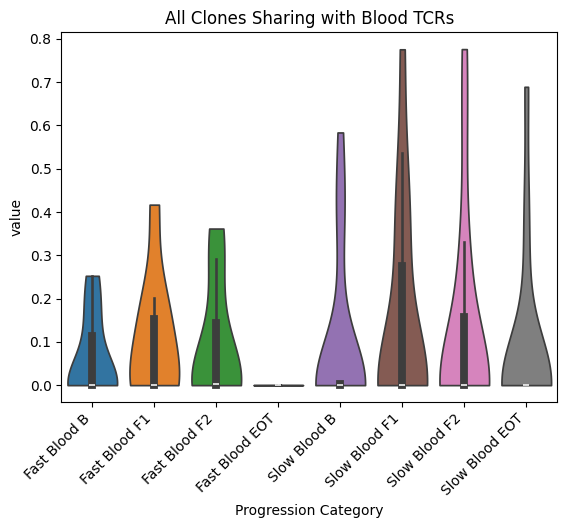

In [30]:
new_clones = pd.DataFrame({
    'Blood B' : new_prop_b,
    'Blood F1' : new_prop_f1,
    'Blood F2' : new_prop_f2,
    'Blood EOT' : new_prop_eot,
    'Progression' : progression
})
new_clones = pd.melt(new_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_clones['Progression Category'] = new_clones['Progression'] + ' ' + new_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('All Clones Sharing with Blood TCRs')
plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/all.pdf',bbox_inches='tight')

In [31]:
progression

{'E30': 'Fast',
 'E15': 'Slow',
 'E43': 'Slow',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E45': 'Slow',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Slow',
 'E18': 'Slow',
 'E20': 'Slow',
 'E46': 'Slow',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'}

In [32]:
lut = dict(zip(['Slow','Fast'], ['tab:blue','tab:orange']))
col_colors = pd.Series(progression).map(lut)

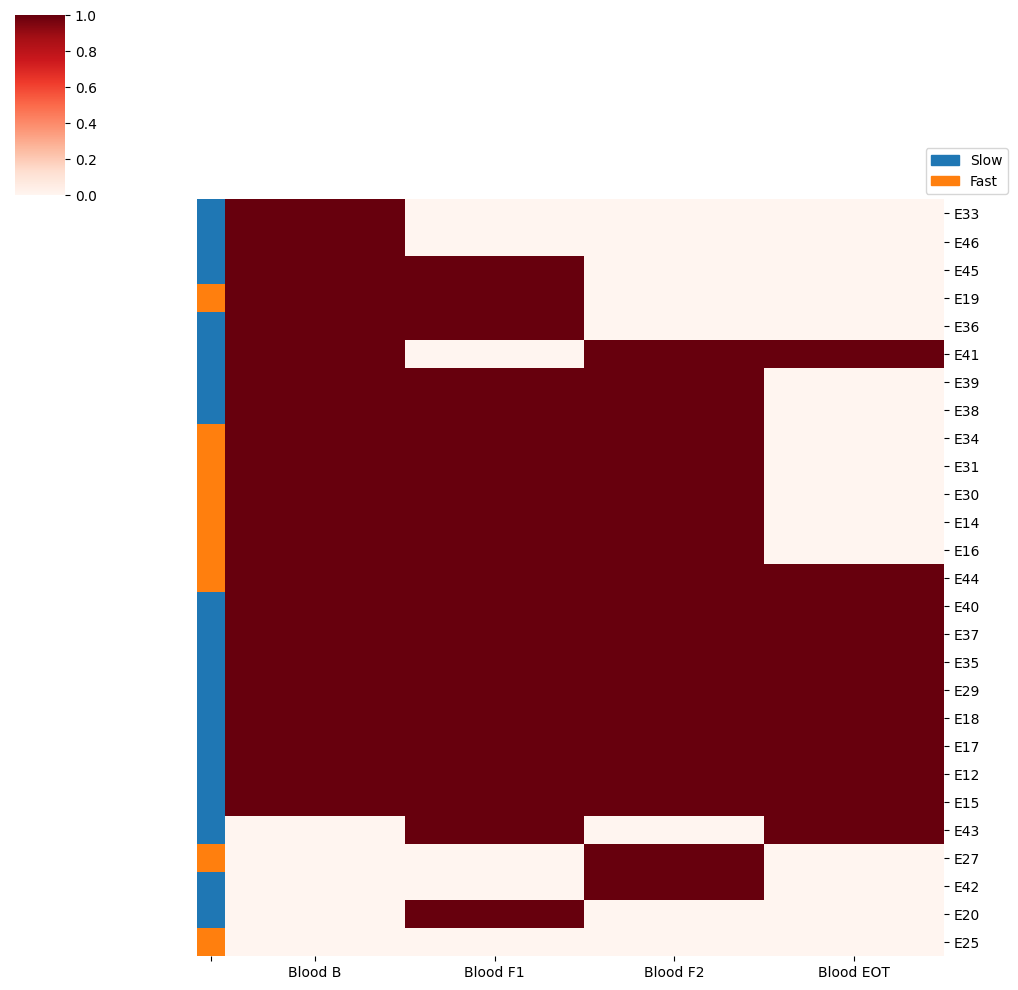

In [33]:
freq_sum_all = pd.DataFrame({
    'Blood B' : new_prop_b,
    'Blood F1' : new_prop_f1,
    'Blood F2' : new_prop_f2,
    'Blood EOT' : new_prop_eot
})
lut = dict(zip(['Slow','Fast'], ['tab:blue','tab:orange']))
col_colors = pd.Series(progression).map(lut)
freq_sum_all[freq_sum_all != 0] = 1
freq_sum_all = freq_sum_all.sort_index()
sns.clustermap(freq_sum_all,cmap='Reds',yticklabels=True,col_cluster=False,
              row_colors=col_colors,tree_kws={"linewidths": 0.})
blue_patch = mpatches.Patch(color='tab:blue', label='Slow') 
orange_patch = mpatches.Patch(color='tab:orange', label='Fast') 
plt.legend(handles=[blue_patch,orange_patch],bbox_to_anchor=(20,0.3)) 

In [34]:
all_clones = pd.DataFrame({
    'Blood B' : new_prop_b,
    'Blood F1' : new_prop_f1,
    'Blood F2' : new_prop_f2,
    'Blood EOT' : new_prop_eot,
    'Progression' : progression
})

In [35]:
new_prop_b_b = {}
new_prop_b_f1 = {}
new_prop_b_f2 = {}
new_prop_b_eot = {}
new_prop_f1_b = {}
new_prop_f1_f1 = {}
new_prop_f1_f2 = {}
new_prop_f1_eot = {}
new_prop_f2_b = {}
new_prop_f2_f1 = {}
new_prop_f2_f2 = {}
new_prop_f2_eot = {}
progression_b = {}
progression_f1 = {}
progression_f2 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_b = temp[temp['Unnamed: 0'].isin(b_clonotypes)].reset_index(drop=True)
        temp_f1 = temp[temp['Unnamed: 0'].isin(f1_clonotypes)].reset_index(drop=True)
        temp_f2 = temp[temp['Unnamed: 0'].isin(f2_clonotypes)].reset_index(drop=True)
        
        new_prop_b_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_b_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_b_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_b_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
        progression_b[i] = temp_b['Progression'][0]
         
        new_prop_f1_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
        progression_f1[i] = temp_f1['Progression'][0]
        if len(temp_f2) > 0:
            new_prop_f2_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f2[i] = temp_f2['Progression'][0]

In [36]:
cdr3_b = {}
cdr3_f1 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_b = temp[temp['Unnamed: 0'].isin(b_clonotypes)].reset_index(drop=True)
        temp_f1 = temp[temp['Unnamed: 0'].isin(f1_clonotypes)].reset_index(drop=True)
        temp_f2 = temp[temp['Unnamed: 0'].isin(f2_clonotypes)].reset_index(drop=True)
        if len(temp_f2) > 0:
            cdr3_b[i] = temp_b[temp_b['Beta CDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Unnamed: 0']
            cdr3_f1[i] = temp_b[temp_b['Beta CDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Unnamed: 0'] 

In [37]:
cdr3_bf1 = np.unique(pd.concat(cdr3_b).tolist() + pd.concat(cdr3_f1).tolist())

In [38]:
len(set(pd.concat(cdr3_b).tolist()) & set(pd.concat(cdr3_f1).tolist()))

347

In [39]:
len(pd.concat(cdr3_b).tolist())

437

In [40]:
len(pd.concat(cdr3_f1).tolist())

697

In [41]:
shared_blood_f2_counts = adata[(adata.obs['clonotype_patient'].isin(cdr3_bf1)) & (
    adata.obs['timepoint'] == 'F2'
)].obs[[
    'annot_final','patient'
]].value_counts().reset_index().pivot(index='patient',columns='annot_final',values=0).fillna(0)

In [42]:
index = list(set(np.unique([i.split('_')[1] for i in cdr3_bf1]).tolist()) ^ set(shared_blood_f2_counts.index))
temp = {}
for i in index:
    temp[i] = len(shared_blood_f2_counts.columns) * [0]

In [43]:
f2_sample_counts = adata[adata.obs['timepoint'] == 'F2'].obs['sample_x'].value_counts()
f2_sample_counts.index = [i.split('_')[0] for i in f2_sample_counts.index]

In [44]:
shared_blood_f2_counts_temp = shared_blood_f2_counts.div(shared_blood_f2_counts.sum(axis=1),axis=0).fillna(0)

In [45]:
shared_blood_f2_counts_extended = pd.concat([
    shared_blood_f2_counts,
    pd.DataFrame(0, 
             index=list(set(new_prop_f2_f1) ^ set(shared_blood_f2_counts.index)), 
             columns=shared_blood_f2_counts.columns)])

In [46]:
shared_blood_f2_counts_extended.index = shared_blood_f2_counts_extended.index.map(patient_progression)

In [47]:
shared_blood_f2_counts.index = shared_blood_f2_counts.index.map(patient_progression)

In [48]:
shared_blood_f2_counts

annot_final,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell,Treg,gd T Cell
patient,,,,,,,,,,,,
Fast,31.0,1.0,19.0,177.0,0.0,22.0,0.0,0.0,0.0,2.0,0.0,2.0
Fast,9.0,0.0,4.0,80.0,0.0,9.0,0.0,0.0,0.0,4.0,0.0,1.0
Slow,9.0,0.0,3.0,195.0,4.0,21.0,2.0,0.0,0.0,0.0,4.0,1.0
Slow,22.0,0.0,11.0,214.0,4.0,35.0,0.0,4.0,1.0,0.0,0.0,2.0
Slow,0.0,0.0,0.0,34.0,0.0,4.0,0.0,0.0,1.0,4.0,0.0,1.0
Fast,1.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Slow,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Slow,3.0,0.0,9.0,82.0,3.0,11.0,4.0,0.0,0.0,0.0,0.0,0.0
Slow,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [49]:
shared_blood_f2_counts = shared_blood_f2_counts.groupby(
    shared_blood_f2_counts.index
).sum()

In [50]:
shared_blood_f2_counts

annot_final,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell,Treg,gd T Cell
patient,,,,,,,,,,,,
Fast,41.0,1.0,28.0,257.0,0.0,31.0,0.0,0.0,0.0,6.0,0.0,3.0
Slow,34.0,0.0,23.0,528.0,12.0,71.0,7.0,4.0,2.0,4.0,5.0,4.0


In [51]:
shared_blood_f2_counts_norm = pd.concat([shared_blood_f2_counts.loc['Fast'] / 2,
          shared_blood_f2_counts.loc['Slow'] / 8],axis=1).T

In [52]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [53]:
shared_blood_f2_counts[['CD8 Cytotoxic T Cell','CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']]

annot_final,CD8 Cytotoxic T Cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell
patient,,,,,,,,,
Fast,41.0,28.0,257.0,0.0,31.0,0.0,0.0,0.0,6.0
Slow,34.0,23.0,528.0,12.0,71.0,7.0,4.0,2.0,4.0


Text(0.5, 1.0, 'Number of cells in all tumor B from\nclonotypes shared with B or F1 blood, div by # patients')

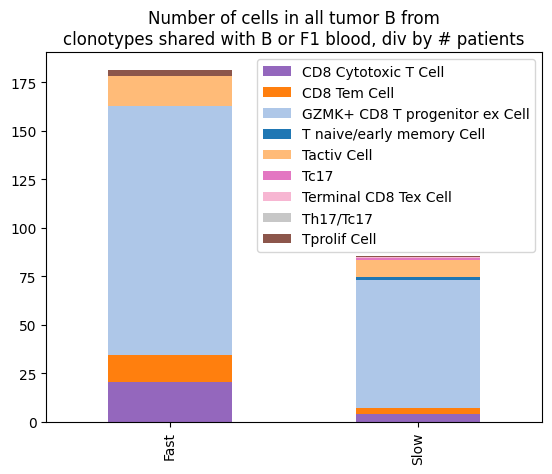

In [54]:
shared_blood_f2_counts_norm[['CD8 Cytotoxic T Cell','CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']].plot(
    kind='bar',stacked=True,color=color_dict
)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Number of cells in all tumor B from\nclonotypes shared with B or F1 blood, div by # patients')

/tmp/ipykernel_4478/2899618492.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,


Text(0.5, 1.0, 'All B Clones Sharing with Blood TCRs')

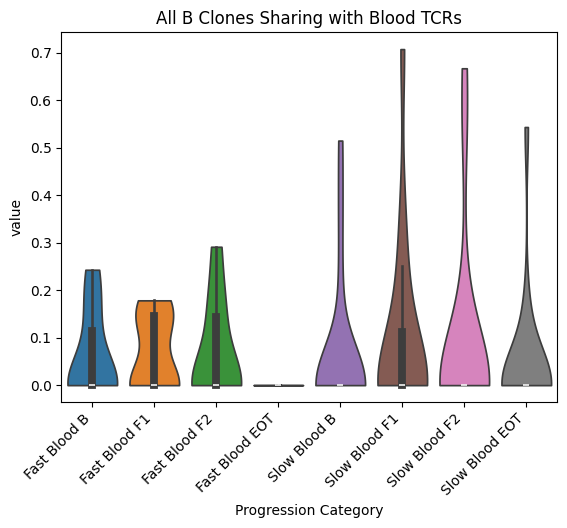

In [55]:
new_b_clones = pd.DataFrame({
    'Blood B' : new_prop_b_b,
    'Blood F1' : new_prop_b_f1,
    'Blood F2' : new_prop_b_f2,
    'Blood EOT' : new_prop_b_eot,
    'Progression' : progression_b 
})
new_b_clones = pd.melt(new_b_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_b_clones['Progression Category'] = new_b_clones['Progression'] + ' ' + new_b_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('All B Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/b_all.pdf',bbox_inches='tight')

In [56]:
all_clones_b = pd.DataFrame({
    'Blood B' : new_prop_b_b,
    'Blood F1' : new_prop_b_f1,
    'Blood F2' : new_prop_b_f2,
    'Blood EOT' : new_prop_b_eot,
    'Progression' : progression_b
})

/tmp/ipykernel_4478/3773033572.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,


Text(0.5, 1.0, 'All F1 Clones Sharing with Blood TCRs')

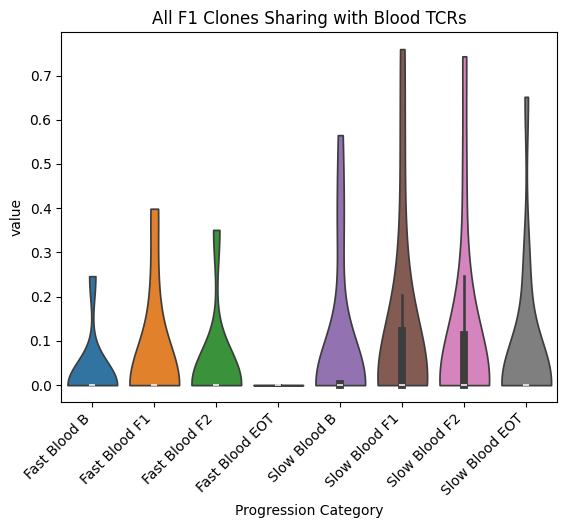

In [57]:
new_f1_clones = pd.DataFrame({
    'Blood B' : new_prop_f1_b,
    'Blood F1' : new_prop_f1_f1,
    'Blood F2' : new_prop_f1_f2,
    'Blood EOT' : new_prop_f1_eot,
    'Progression' : progression_f1 
})
new_f1_clones = pd.melt(new_f1_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f1_clones['Progression Category'] = new_f1_clones['Progression'] + ' ' + new_f1_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('All F1 Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/f1_all.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/977888054.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,


Text(0.5, 1.0, 'All F2 Clones Sharing with Blood TCRs')

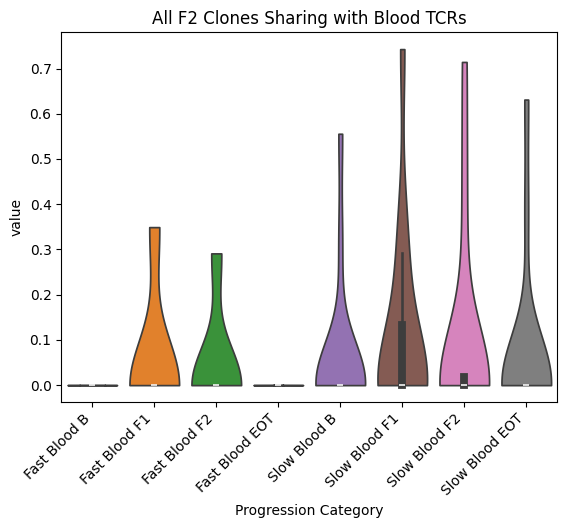

In [58]:
new_f2_clones = pd.DataFrame({
    'Blood B' : new_prop_f2_b,
    'Blood F1' : new_prop_f2_f1,
    'Blood F2' : new_prop_f2_f2,
    'Blood EOT' : new_prop_f2_eot,
    'Progression' : progression_f2
})
new_f2_clones = pd.melt(new_f2_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f2_clones['Progression Category'] = new_f2_clones['Progression'] + ' ' + new_f2_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('All F2 Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/f2_all.pdf',bbox_inches='tight')

In [59]:
all_clones_f2 = pd.DataFrame({
    'Blood B' : new_prop_f2_b,
    'Blood F1' : new_prop_f2_f1,
    'Blood F2' : new_prop_f2_f2,
    'Blood EOT' : new_prop_f2_eot,
    'Progression' : progression_f2
})

In [60]:
#new clones
new_prop_f1_b = {}
new_prop_f1_f1 = {}
new_prop_f1_f2 = {}
new_prop_f1_eot = {}
new_prop_f2_b = {}
new_prop_f2_f1 = {}
new_prop_f2_f2 = {}
new_prop_f2_eot = {}
progression_f1 = {}
progression_f2 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_f1 = temp[temp['New Status'] == 'New F1'].reset_index(drop=True)
        temp_f2 = temp[temp['New Status'] == 'New F2'].reset_index(drop=True)
        
        new_prop_f1_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
        progression_f1[i] = temp_f1['Progression'][0]
        if len(temp_f2) > 0:
            new_prop_f2_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f2[i] = temp_f2['Progression'][0]

In [61]:
cdr3_b = {}
cdr3_f1 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_f1 = temp[temp['New Status'] == 'New F1'].reset_index(drop=True)
        temp_f2 = temp[temp['New Status'] == 'New F2'].reset_index(drop=True)
        if len(temp_f2) > 0:
            cdr3_b[i] = temp_f1[temp_f1['Beta CDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Unnamed: 0']
            cdr3_f1[i] = temp_f1[temp_f1['Beta CDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Unnamed: 0'] 

In [62]:
cdr3_bf1 = np.unique(pd.concat(cdr3_b).tolist() + pd.concat(cdr3_f1).tolist())

In [63]:
len(set(pd.concat(cdr3_b).tolist()) & set(pd.concat(cdr3_f1).tolist()))

174

In [64]:
len(pd.concat(cdr3_b).tolist())

229

In [65]:
len(pd.concat(cdr3_f1).tolist())

505

In [66]:
shared_blood_f2_counts = adata[(adata.obs['clonotype_patient'].isin(cdr3_bf1)) & (
    adata.obs['timepoint'] == 'F2'
)].obs[[
    'annot_final','patient'
]].value_counts().reset_index().pivot(index='patient',columns='annot_final',values=0).fillna(0)

In [67]:
index = list(set(np.unique([i.split('_')[1] for i in cdr3_bf1]).tolist()) ^ set(shared_blood_f2_counts.index))
temp = {}
for i in index:
    temp[i] = len(shared_blood_f2_counts.columns) * [0]

In [68]:
f2_sample_counts = adata[adata.obs['timepoint'] == 'F2'].obs['sample_x'].value_counts()
f2_sample_counts.index = [i.split('_')[0] for i in f2_sample_counts.index]

In [69]:
shared_blood_f2_counts_temp = shared_blood_f2_counts.div(shared_blood_f2_counts.sum(axis=1),axis=0).fillna(0)

In [70]:
shared_blood_f2_counts_extended = pd.concat([
    shared_blood_f2_counts,
    pd.DataFrame(0, 
             index=list(set(new_prop_f2_f1) ^ set(shared_blood_f2_counts.index)), 
             columns=shared_blood_f2_counts.columns)])

In [71]:
shared_blood_f2_counts_extended.index = shared_blood_f2_counts_extended.index.map(patient_progression)

In [72]:
shared_blood_f2_counts.index = shared_blood_f2_counts.index.map(patient_progression)

In [73]:
shared_blood_f2_counts

annot_final,CD8 Cytotoxic T Cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,NKT,T naive/early memory Cell,Tactiv Cell,Th17/Tc17,Tprolif Cell,Treg,gd T Cell
patient,,,,,,,,,,
Fast,2.0,16.0,77.0,1.0,0.0,10.0,2.0,1.0,0.0,0.0
Fast,9.0,0.0,18.0,0.0,1.0,2.0,0.0,2.0,0.0,5.0
Slow,1.0,8.0,68.0,0.0,2.0,8.0,0.0,1.0,0.0,0.0
Slow,1.0,1.0,18.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0
Slow,0.0,0.0,9.0,0.0,0.0,2.0,0.0,0.0,3.0,1.0
Fast,0.0,10.0,1.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0
Slow,0.0,4.0,9.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0
Slow,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
shared_blood_f2_counts = shared_blood_f2_counts.groupby(
    shared_blood_f2_counts.index
).sum()

In [75]:
shared_blood_f2_counts

annot_final,CD8 Cytotoxic T Cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,NKT,T naive/early memory Cell,Tactiv Cell,Th17/Tc17,Tprolif Cell,Treg,gd T Cell
patient,,,,,,,,,,
Fast,11.0,26.0,96.0,1.0,2.0,15.0,2.0,3.0,0.0,5.0
Slow,2.0,14.0,104.0,0.0,4.0,14.0,0.0,1.0,4.0,1.0


In [76]:
shared_blood_f2_counts_norm = pd.concat([shared_blood_f2_counts.loc['Fast'] / 2,
          shared_blood_f2_counts.loc['Slow'] / 6],axis=1).T

In [77]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [78]:
shared_blood_f2_counts[['CD8 Cytotoxic T Cell', 'CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Th17/Tc17', 'Tprolif Cell']]

annot_final,CD8 Cytotoxic T Cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Th17/Tc17,Tprolif Cell
patient,,,,,,,
Fast,11.0,26.0,96.0,2.0,15.0,2.0,3.0
Slow,2.0,14.0,104.0,4.0,14.0,0.0,1.0


Text(0.5, 1.0, 'Number of cells in new tumor F1 from\nclonotypes shared with B or F1 blood, div by # patients')

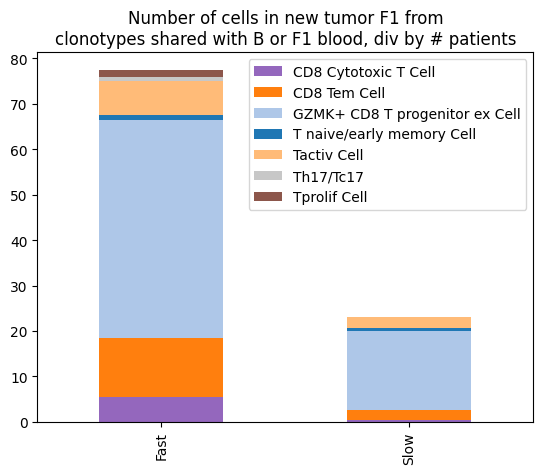

In [79]:
shared_blood_f2_counts_norm[['CD8 Cytotoxic T Cell', 'CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Th17/Tc17', 'Tprolif Cell']].plot(
    kind='bar',stacked=True,color=color_dict
)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Number of cells in new tumor F1 from\nclonotypes shared with B or F1 blood, div by # patients')

/tmp/ipykernel_4478/2520259860.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,


Text(0.5, 1.0, 'New Clones at F1 Sharing with Blood TCRs')

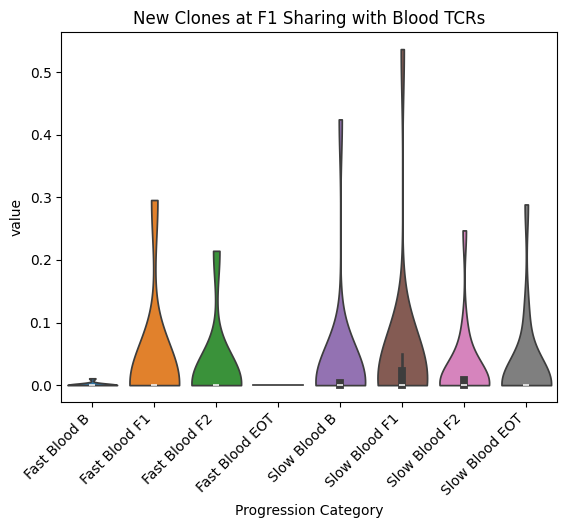

In [80]:
new_f1_clones = pd.DataFrame({
    'Blood B' : new_prop_f1_b,
    'Blood F1' : new_prop_f1_f1,
    'Blood F2' : new_prop_f1_f2,
    'Blood EOT' : new_prop_f1_eot,
    'Progression' : progression_f1 
})
new_f1_clones = pd.melt(new_f1_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f1_clones['Progression Category'] = new_f1_clones['Progression'] + ' ' + new_f1_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('New Clones at F1 Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/new_f1.pdf',bbox_inches='tight')

In [81]:
new_f1_clones_df = pd.DataFrame({
    'Blood B' : new_prop_f1_b,
    'Blood F1' : new_prop_f1_f1,
    'Blood F2' : new_prop_f1_f2,
    'Blood EOT' : new_prop_f1_eot,
    'Progression' : progression_f1
})

/tmp/ipykernel_4478/1895749709.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,


Text(0.5, 1.0, 'New Clones at F2 Sharing with Blood TCRs')

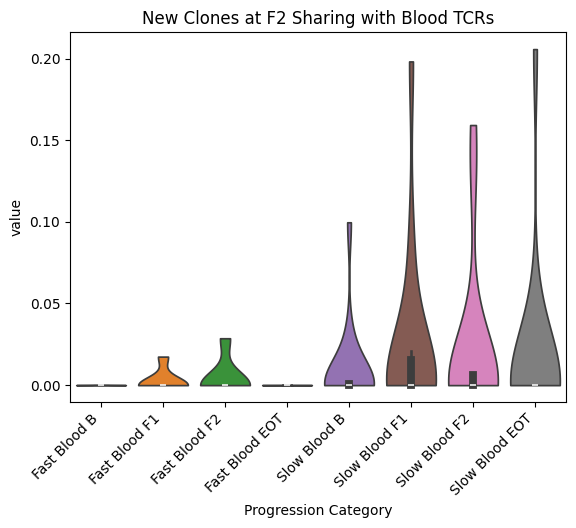

In [82]:
new_f2_clones = pd.DataFrame({
    'Blood B' : new_prop_f2_b,
    'Blood F1' : new_prop_f2_f1,
    'Blood F2' : new_prop_f2_f2,
    'Blood EOT' : new_prop_f2_eot,
    'Progression' : progression_f2
})
new_f2_clones = pd.melt(new_f2_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f2_clones['Progression Category'] = new_f2_clones['Progression'] + ' ' + new_f2_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('New Clones at F2 Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/new_f2.pdf',bbox_inches='tight')

In [83]:
#new clones
new_prop_b_b = {}
new_prop_b_f1 = {}
new_prop_b_f2 = {}
new_prop_b_eot = {}
new_prop_f1_b = {}
new_prop_f1_f1 = {}
new_prop_f1_f2 = {}
new_prop_f1_eot = {}
new_prop_f2_b = {}
new_prop_f2_f1 = {}
new_prop_f2_f2 = {}
new_prop_f2_eot = {}
progression_b = {}
progression_f1 = {}
progression_f2 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_b = temp[temp['Sharing Status'] == 'B Only'].reset_index(drop=True)
        temp_f1 = temp[temp['Sharing Status'] == 'F1 Only'].reset_index(drop=True)
        temp_f2 = temp[temp['Sharing Status'] == 'F2 Only'].reset_index(drop=True)
        
        new_prop_b_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_b_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_b_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_b_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
        progression_b[i] = temp_b['Progression'][0]
         
        new_prop_f1_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
        new_prop_f1_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
        progression_f1[i] = temp_f1['Progression'][0]
        if len(temp_f2) > 0:
            new_prop_f2_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f2[i] = temp_f2['Progression'][0]
            

Text(0.5, 1.0, 'Frequencies of B + F1 clones shared with F2 tumor')

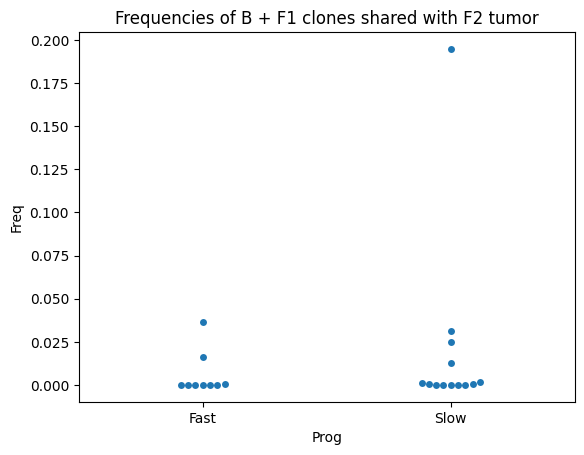

In [84]:
freq_temp = pd.DataFrame(
    {'Freq':pd.Series(new_prop_f2_b) + pd.Series(new_prop_f2_f1),
              'Prog':(pd.Series(new_prop_f2_b) + pd.Series(new_prop_f2_f1)).index.map(patient_progression)})
sns.swarmplot(data=freq_temp,x='Prog',y='Freq')
plt.title('Frequencies of B + F1 clones shared with F2 tumor')

In [85]:
patient_progression

{'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'}

In [86]:
cdr3_b = {}
cdr3_f1 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_b = temp[temp['Sharing Status'] == 'B Only'].reset_index(drop=True)
        temp_f1 = temp[temp['Sharing Status'] == 'F1 Only'].reset_index(drop=True)
        temp_f2 = temp[temp['Sharing Status'] == 'F2 Only'].reset_index(drop=True)
        if len(temp_f2) > 0:
            cdr3_b[i] = temp_f2[temp_f2['Beta CDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Unnamed: 0']
            cdr3_f1[i] = temp_f2[temp_f2['Beta CDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Unnamed: 0']
            

In [87]:
cdr3_bf1 = np.unique(pd.concat(cdr3_b).tolist() + pd.concat(cdr3_f1).tolist())

In [88]:
len(set(pd.concat(cdr3_b).tolist()) & set(pd.concat(cdr3_f1).tolist()))

80

In [89]:
len(pd.concat(cdr3_b).tolist())

125

In [90]:
len(pd.concat(cdr3_f1).tolist())

306

In [91]:
shared_blood_f2_counts = adata[(adata.obs['clonotype_patient'].isin(cdr3_bf1)) & (
    adata.obs['timepoint'] == 'F2'
)].obs[[
    'annot_final','patient'
]].value_counts().reset_index().pivot(index='patient',columns='annot_final',values=0).fillna(0)

In [92]:
index = list(set(np.unique([i.split('_')[1] for i in cdr3_bf1]).tolist()) ^ set(shared_blood_f2_counts.index))
temp = {}
for i in index:
    temp[i] = len(shared_blood_f2_counts.columns) * [0]

In [93]:
f2_sample_counts = adata[adata.obs['timepoint'] == 'F2'].obs['sample_x'].value_counts()
f2_sample_counts.index = [i.split('_')[0] for i in f2_sample_counts.index]

In [94]:
temp_df =pd.concat([(pd.Series(new_prop_f2_f1) + pd.Series(new_prop_f2_b)),
           shared_blood_f2_counts['GZMK+ CD8 T progenitor ex Cell']],axis=1)
temp_df.columns = ['Blood F1/Tumor F2 frequency','GZMK+ CD8 T progenitor ex Cell']
temp_df['GZMK+ CD8 T progenitor ex Cell'] = temp_df['GZMK+ CD8 T progenitor ex Cell'] / f2_sample_counts
temp_df['Blood F1/Tumor F2 frequency'] = np.log10(temp_df['Blood F1/Tumor F2 frequency'])
mask = temp_df['Blood F1/Tumor F2 frequency'] == -np.inf
temp_df=temp_df[~mask]
temp_df['Progression'] = temp_df.index.map(patient_progression)

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Progression', ylabel='GZMK+ CD8 T progenitor ex Cell'>

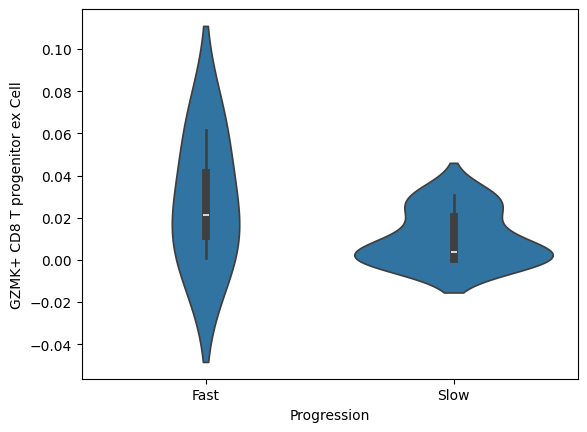

In [95]:
sns.violinplot(data=temp_df,y='GZMK+ CD8 T progenitor ex Cell',x='Progression')

Text(0.5, 0, 'Blood B + F1/Tumor F2 Frequency')

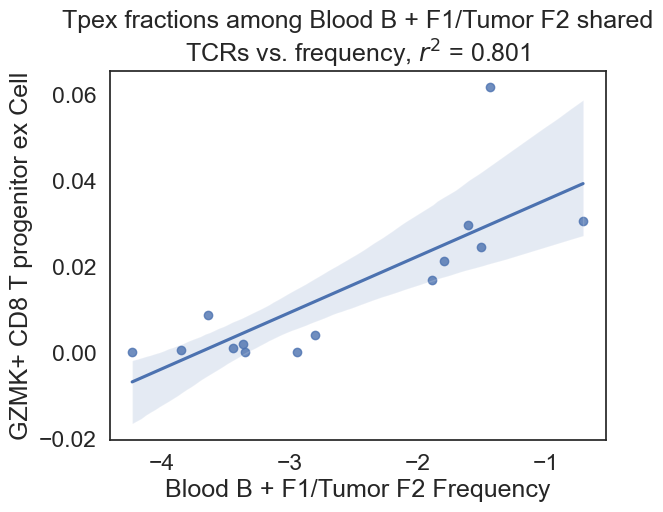

In [96]:
sns.set(font_scale=1.5)
sns.set_style('white')
sns.regplot(data=temp_df,x='Blood F1/Tumor F2 frequency',y='GZMK+ CD8 T progenitor ex Cell')
plt.title('Tpex fractions among Blood B + F1/Tumor F2 shared\nTCRs vs. frequency, $r^2$ = 0.801')
plt.xlabel('Blood B + F1/Tumor F2 Frequency')

In [97]:
from scipy.stats import linregress
linregress(temp_df['Blood F1/Tumor F2 frequency'],
          temp_df['GZMK+ CD8 T progenitor ex Cell'])

LinregressResult(slope=0.013098187911287426, intercept=0.04850865109723521, rvalue=0.8014152873149201, pvalue=0.0005686076597366933, stderr=0.0028219076673819178, intercept_stderr=0.007946817728660339)

In [98]:
shared_blood_f2_counts_temp = shared_blood_f2_counts.div(shared_blood_f2_counts.sum(axis=1),axis=0).fillna(0)

In [99]:
temp_df =pd.concat([pd.Series(new_prop_f2_f1),
           shared_blood_f2_counts_temp['GZMK+ CD8 T progenitor ex Cell']],axis=1)
temp_df.columns = ['Blood F1/Tumor F2 frequency','GZMK+ CD8 T progenitor ex Cell']

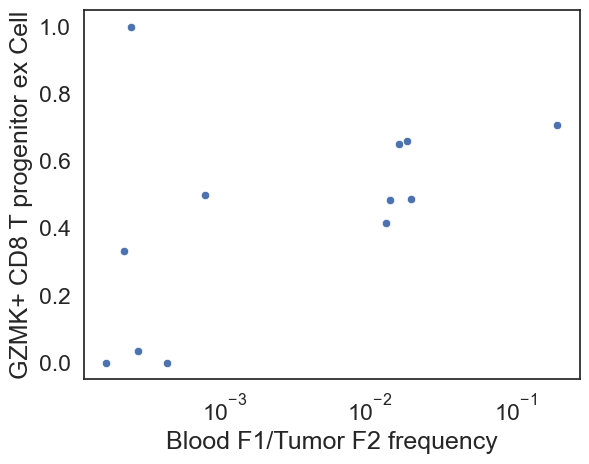

In [100]:
sns.scatterplot(data=temp_df,x='Blood F1/Tumor F2 frequency',
                y='GZMK+ CD8 T progenitor ex Cell')
plt.xscale('log')

In [101]:
set(new_prop_f2_b)

{'E12',
 'E15',
 'E16',
 'E17',
 'E18',
 'E20',
 'E25',
 'E27',
 'E29',
 'E30',
 'E31',
 'E35',
 'E36',
 'E37',
 'E38',
 'E39',
 'E40',
 'E41',
 'E42',
 'E44',
 'E45',
 'E46'}

In [102]:
len(set(new_prop_f2_b))

22

In [103]:
shared_blood_f2_counts_extended = pd.concat([
    shared_blood_f2_counts,
    pd.DataFrame(0, 
             index=list(set(new_prop_f2_f1) ^ set(shared_blood_f2_counts.index)), 
             columns=shared_blood_f2_counts.columns)])

In [104]:
shared_blood_f2_counts_extended.index = shared_blood_f2_counts_extended.index.map(patient_progression)

In [105]:
shared_blood_f2_counts.index = shared_blood_f2_counts.index.map(patient_progression)

In [106]:
len(new_prop_f2_f1.keys())

22

In [107]:
shared_blood_f2_counts_extended.div(shared_blood_f2_counts_extended.sum(axis=1),axis=0)

annot_final,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell,Treg,gd T Cell
Fast,0.027211,0.000000,0.061224,0.659864,0.020408,0.115646,0.013605,0.000000,0.061224,0.006803,0.034014,0.000000
Slow,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fast,0.023256,0.000000,0.093023,0.651163,0.023256,0.116279,0.000000,0.000000,0.000000,0.069767,0.023256,0.000000
Slow,0.058394,0.007299,0.058394,0.708029,0.007299,0.102190,0.021898,0.000000,0.000000,0.014599,0.014599,0.007299
Slow,0.058824,0.000000,0.147059,0.485294,0.014706,0.176471,0.014706,0.058824,0.029412,0.014706,0.000000,0.000000
Slow,0.000000,0.000000,0.024390,0.414634,0.000000,0.219512,0.048780,0.000000,0.195122,0.073171,0.024390,0.000000
Fast,0.000000,0.000000,0.620690,0.034483,0.034483,0.310345,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Slow,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Slow,0.000000,0.000000,0.166667,0.500000,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Slow,0.000000,0.000000,0.666667,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


/tmp/ipykernel_4478/548233375.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


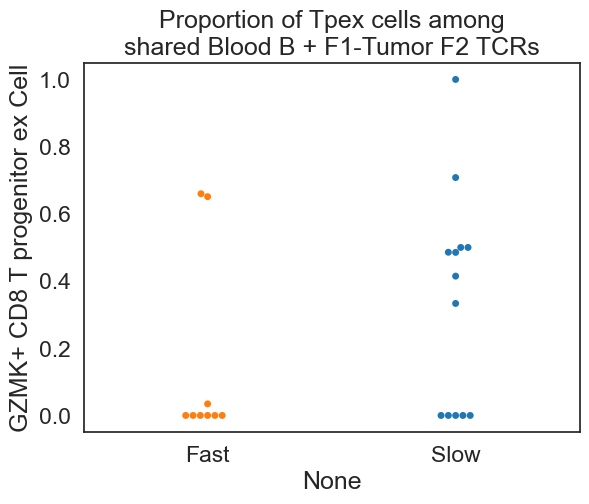

In [108]:
sns.swarmplot(
    data=shared_blood_f2_counts_extended.div(shared_blood_f2_counts_extended.sum(axis=1),axis=0).fillna(0),
    y='GZMK+ CD8 T progenitor ex Cell',
    x=shared_blood_f2_counts_extended.div(shared_blood_f2_counts_extended.sum(axis=1),axis=0).fillna(0).index,
order=['Fast','Slow'],palette={'Fast':'tab:orange','Slow':'tab:blue'})
plt.title('Proportion of Tpex cells among\nshared Blood B + F1-Tumor F2 TCRs')
plt.show()

In [109]:
temp_shared_tpex = shared_blood_f2_counts_extended.div(shared_blood_f2_counts_extended.sum(axis=1),axis=0).fillna(0)

In [110]:
from scipy.stats import ranksums
ranksums(
    temp_shared_tpex[temp_shared_tpex.index == 'Slow']['GZMK+ CD8 T progenitor ex Cell'],
    temp_shared_tpex[temp_shared_tpex.index == 'Fast']['GZMK+ CD8 T progenitor ex Cell'])

RanksumsResult(statistic=1.1018379294353935, pvalue=0.27053213743164606)

In [111]:
shared_blood_f2_counts = shared_blood_f2_counts.groupby(
    shared_blood_f2_counts.index
).sum()

In [112]:
shared_blood_f2_counts

annot_final,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell,Treg,gd T Cell
patient,,,,,,,,,,,,
Fast,5.0,0.0,31.0,126.0,5.0,31.0,2.0,0.0,9.0,4.0,6.0,0.0
Slow,12.0,1.0,29.0,171.0,2.0,57.0,11.0,4.0,13.0,6.0,3.0,2.0


In [113]:
shared_blood_f2_counts_norm = pd.concat([shared_blood_f2_counts.loc['Fast'] / 2,
          shared_blood_f2_counts.loc['Slow'] / 12],axis=1).T

In [114]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [115]:
shared_blood_f2_counts[['CD8 Cytotoxic T Cell', 'CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']]

annot_final,CD8 Cytotoxic T Cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell
patient,,,,,,,,,
Fast,5.0,31.0,126.0,5.0,31.0,2.0,0.0,9.0,4.0
Slow,12.0,29.0,171.0,2.0,57.0,11.0,4.0,13.0,6.0


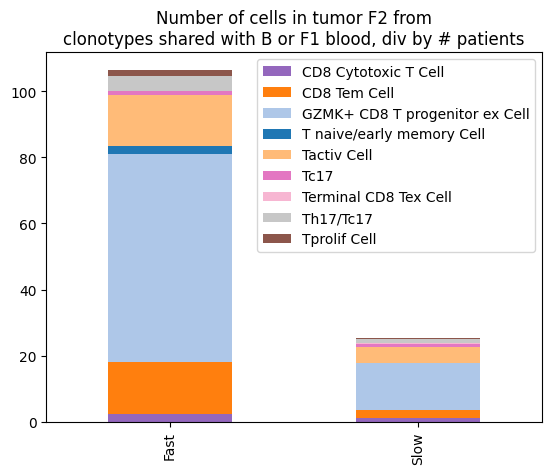

In [116]:
sns.reset_defaults()
shared_blood_f2_counts_norm[['CD8 Cytotoxic T Cell','CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']].plot(
    kind='bar',stacked=True,color=color_dict
)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Number of cells in tumor F2 from\nclonotypes shared with B or F1 blood, div by # patients')
plt.show()

In [117]:
shared_blood_f2_counts_norm[['CD8 Cytotoxic T Cell', 'CD8 HSP T cell', 'CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']].div(
    shared_blood_f2_counts_norm[['CD8 Cytotoxic T Cell', 'CD8 HSP T cell', 'CD8 Tem Cell',
                  'GZMK+ CD8 T progenitor ex Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']].sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict
)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Proportion of cells in tumor F2 from\nclonotypes shared with B or F1 blood')

Text(0.5, 1.0, 'Proportion of cells in tumor F2 from\nclonotypes shared with B or F1 blood')

In [118]:
new_b_clones = pd.DataFrame({
    'Blood B' : new_prop_b_b,
    'Blood F1' : new_prop_b_f1,
    'Blood F2' : new_prop_b_f2,
    'Blood EOT' : new_prop_b_eot,
    'Progression' : progression_b 
})
new_b_clones = pd.melt(new_b_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_b_clones['Progression Category'] = new_b_clones['Progression'] + ' ' + new_b_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('B Only Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/b_only.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/527382671.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,


Text(0.5, 1.0, 'B Only Clones Sharing with Blood TCRs')

In [119]:
new_f1_clones = pd.DataFrame({
    'Blood B' : new_prop_f1_b,
    'Blood F1' : new_prop_f1_f1,
    'Blood F2' : new_prop_f1_f2,
    'Blood EOT' : new_prop_f1_eot,
    'Progression' : progression_f1 
})
new_f1_clones = pd.melt(new_f1_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f1_clones['Progression Category'] = new_f1_clones['Progression'] + ' ' + new_f1_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('F1 Only Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/f1_only.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/1767566019.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,


Text(0.5, 1.0, 'F1 Only Clones Sharing with Blood TCRs')

In [120]:
new_f2_clones = pd.DataFrame({
    'Blood B' : new_prop_f2_b,
    'Blood F1' : new_prop_f2_f1,
    'Blood F2' : new_prop_f2_f2,
    'Blood EOT' : new_prop_f2_eot,
    'Progression' : progression_f2
})
new_f2_clones = pd.melt(new_f2_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f2_clones['Progression Category'] = new_f2_clones['Progression'] + ' ' + new_f2_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('F2 Only Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/f2_only.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/575834430.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,


Text(0.5, 1.0, 'F2 Only Clones Sharing with Blood TCRs')

In [121]:
cdr3_f1['E16']

35     12194_E16
42     12201_E16
54      6286_E16
60      6352_E16
63     12224_E16
73     12238_E16
81     12248_E16
156    12348_E16
164    12361_E16
166    12370_E16
199    12421_E16
205    12428_E16
295    12562_E16
337    12620_E16
339    12623_E16
409    12722_E16
438    12768_E16
Name: Unnamed: 0, dtype: object

In [122]:
f2_only_clones = pd.DataFrame({
    'Blood B' : new_prop_f2_b,
    'Blood F1' : new_prop_f2_f1,
    'Blood F2' : new_prop_f2_f2,
    'Blood EOT' : new_prop_f2_eot,
    'Progression' : progression_f2 
})

In [123]:
sns.swarmplot(
    data=f2_only_clones.sort_values('Progression')[['Blood F1','Progression']],
    x='Progression',y='Blood F1')

<Axes: title={'center': 'F2 Only Clones Sharing with Blood TCRs'}, xlabel='Progression Category', ylabel='value'>

In [124]:
from scipy.stats import ranksums
ranksums(f2_only_clones[f2_only_clones['Progression']=='Slow']['Blood B'],
         f2_only_clones[f2_only_clones['Progression']=='Fast']['Blood B'])

RanksumsResult(statistic=1.9167454300136628, pvalue=0.05527028067627238)

In [125]:
#new clones
new_prop_b_b = {}
new_prop_b_f1 = {}
new_prop_b_f2 = {}
new_prop_b_eot = {}
new_prop_f1_b = {}
new_prop_f1_f1 = {}
new_prop_f1_f2 = {}
new_prop_f1_eot = {}
new_prop_f2_b = {}
new_prop_f2_f1 = {}
new_prop_f2_f2 = {}
new_prop_f2_eot = {}
progression_b = {}
progression_f1 = {}
progression_f2 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_b = temp[temp['Sharing Status'] == 'All Timepoints Shared'].reset_index(drop=True)
        temp_f1 = temp[temp['Sharing Status'] == 'B-F1 Shared Only'].reset_index(drop=True)
        temp_f2 = temp[temp['Sharing Status'] == 'F1-F2 Shared Only'].reset_index(drop=True)

        if len(temp_b) > 0:
            new_prop_b_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_b_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_b_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_b_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_b[i] = temp_b['Progression'][0]
        if len(temp_f1) > 0:
            new_prop_f1_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f1_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f1_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f1_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f1[i] = temp_f1['Progression'][0]
        if len(temp_f2) > 0:
            new_prop_f2_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f2[i] = temp_f2['Progression'][0]

In [126]:
new_b_clones = pd.DataFrame({
    'Blood B' : new_prop_b_b,
    'Blood F1' : new_prop_b_f1,
    'Blood F2' : new_prop_b_f2,
    'Blood EOT' : new_prop_b_eot,
    'Progression' : progression_b 
})
new_b_clones = pd.melt(new_b_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_b_clones['Progression Category'] = new_b_clones['Progression'] + ' ' + new_b_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('All Timepoints Shared Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/all_shared.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/689079156.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,


Text(0.5, 1.0, 'All Timepoints Shared Clones Sharing with Blood TCRs')

In [127]:
all_timepoints_shared_df = pd.DataFrame({
    'Blood B' : new_prop_b_b,
    'Blood F1' : new_prop_b_f1,
    'Blood F2' : new_prop_b_f2,
    'Blood EOT' : new_prop_b_eot,
    'Progression' : progression_b 
})

In [128]:
new_f1_clones = pd.DataFrame({
    'Blood B' : new_prop_f1_b,
    'Blood F1' : new_prop_f1_f1,
    'Blood F2' : new_prop_f1_f2,
    'Blood EOT' : new_prop_f1_eot,
    'Progression' : progression_f1 
})
new_f1_clones = pd.melt(new_f1_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f1_clones['Progression Category'] = new_f1_clones['Progression'] + ' ' + new_f1_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('B-F1 Shared Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/bf1_shared.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/2541115394.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,


Text(0.5, 1.0, 'B-F1 Shared Clones Sharing with Blood TCRs')

In [129]:
new_f2_clones = pd.DataFrame({
    'Blood B' : new_prop_f2_b,
    'Blood F1' : new_prop_f2_f1,
    'Blood F2' : new_prop_f2_f2,
    'Blood EOT' : new_prop_f2_eot,
    'Progression' : progression_f2
})
new_f2_clones = pd.melt(new_f2_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f2_clones['Progression Category'] = new_f2_clones['Progression'] + ' ' + new_f2_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('F1-F2 Shared Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250121_freq_blood_violin/f1f2_shared.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/1337300174.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,


Text(0.5, 1.0, 'F1-F2 Shared Clones Sharing with Blood TCRs')

In [130]:
#new clones
new_prop_b_b = {}
new_prop_b_f1 = {}
new_prop_b_f2 = {}
new_prop_b_eot = {}
new_prop_f1_b = {}
new_prop_f1_f1 = {}
new_prop_f1_f2 = {}
new_prop_f1_eot = {}
new_prop_f2_b = {}
new_prop_f2_f1 = {}
new_prop_f2_f2 = {}
new_prop_f2_eot = {}
new_prop_f3_b = {}
new_prop_f3_f1 = {}
new_prop_f3_f2 = {}
new_prop_f3_eot = {}
progression_b = {}
progression_f1 = {}
progression_f2 = {}
progression_f3 = {}
for i in tumor['Patient'].unique():
    if i in blood['patient'].unique():
        temp = tumor[tumor['Patient'] == i]
        temp_blood = blood[blood['patient'] == i]
        temp_blood_b = temp_blood[temp_blood['timepoint'] == 'B']
        temp_blood_f1 = temp_blood[temp_blood['timepoint'] == 'FU1']
        temp_blood_f2 = temp_blood[temp_blood['timepoint'] == 'FU2']
        temp_blood_eot = temp_blood[temp_blood['timepoint'] == 'EOT']
        temp_b = temp[temp['Unnamed: 0'].isin(expanding_clones_bf1)].reset_index(drop=True)
        temp_f1 = temp[temp['Unnamed: 0'].isin(expanding_clones_f1f2)].reset_index(drop=True)
        temp_f2 = temp[temp['Unnamed: 0'].isin(contracting_clones_bf1)].reset_index(drop=True)
        temp_f3 = temp[temp['Unnamed: 0'].isin(contracting_clones_f1f2)].reset_index(drop=True)

        if len(temp_b) > 0:
            new_prop_b_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_b_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_b_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_b_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_b['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_b[i] = temp_b['Progression'][0]
        if len(temp_f1) > 0:
            new_prop_f1_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f1_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f1_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f1_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f1['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f1[i] = temp_f1['Progression'][0]
        if len(temp_f2) > 0:
            new_prop_f2_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f2_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f2['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f2[i] = temp_f2['Progression'][0]
        if len(temp_f3) > 0:
            new_prop_f3_b[i] = temp_blood_b[temp_blood_b['aaSeqCDR3'].isin(list(set(temp_f3['Beta CDR3']) & set(temp_blood_b['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f3_f1[i] = temp_blood_f1[temp_blood_f1['aaSeqCDR3'].isin(list(set(temp_f3['Beta CDR3']) & set(temp_blood_f1['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f3_f2[i] = temp_blood_f2[temp_blood_f2['aaSeqCDR3'].isin(list(set(temp_f3['Beta CDR3']) & set(temp_blood_f2['aaSeqCDR3'])))]['Freq'].sum()
            new_prop_f3_eot[i] = temp_blood_eot[temp_blood_eot['aaSeqCDR3'].isin(list(set(temp_f3['Beta CDR3']) & set(temp_blood_eot['aaSeqCDR3'])))]['Freq'].sum()
            progression_f3[i] = temp_f3['Progression'][0]

In [131]:
new_b_clones = pd.DataFrame({
    'Blood B' : new_prop_b_b,
    'Blood F1' : new_prop_b_f1,
    'Blood F2' : new_prop_b_f2,
    'Blood EOT' : new_prop_b_eot,
    'Progression' : progression_b 
})
new_b_clones = pd.melt(new_b_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_b_clones['Progression Category'] = new_b_clones['Progression'] + ' ' + new_b_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('Expanding B-F1 Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250208_freq_blood_violin/expanding_bf1.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/3554254518.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_b_clones,cut=0,


Text(0.5, 1.0, 'Expanding B-F1 Clones Sharing with Blood TCRs')

In [132]:
new_f1_clones = pd.DataFrame({
    'Blood B' : new_prop_f1_b,
    'Blood F1' : new_prop_f1_f1,
    'Blood F2' : new_prop_f1_f2,
    'Blood EOT' : new_prop_f1_eot,
    'Progression' : progression_f1 
})
new_f1_clones = pd.melt(new_f1_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f1_clones['Progression Category'] = new_f1_clones['Progression'] + ' ' + new_f1_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('Expanding F1-F2 Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250208_freq_blood_violin/expanding_f1f2.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/3245290117.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f1_clones,cut=0,


Text(0.5, 1.0, 'Expanding F1-F2 Clones Sharing with Blood TCRs')

In [133]:
new_f2_clones = pd.DataFrame({
    'Blood B' : new_prop_f2_b,
    'Blood F1' : new_prop_f2_f1,
    'Blood F2' : new_prop_f2_f2,
    'Blood EOT' : new_prop_f2_eot,
    'Progression' : progression_f2
})
new_f2_clones = pd.melt(new_f2_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f2_clones['Progression Category'] = new_f2_clones['Progression'] + ' ' + new_f2_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('Contracting B-F1 Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250208_freq_blood_violin/contracting_bf1.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/769299060.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f2_clones,cut=0,


Text(0.5, 1.0, 'Contracting B-F1 Clones Sharing with Blood TCRs')

In [134]:
new_f3_clones = pd.DataFrame({
    'Blood B' : new_prop_f3_b,
    'Blood F1' : new_prop_f3_f1,
    'Blood F2' : new_prop_f3_f2,
    'Blood EOT' : new_prop_f3_eot,
    'Progression' : progression_f3
})
new_f3_clones = pd.melt(new_f3_clones,id_vars=['Progression'],
       value_vars=['Blood B','Blood F1','Blood F2','Blood EOT'])
new_f3_clones['Progression Category'] = new_f3_clones['Progression'] + ' ' + new_f3_clones['variable']
sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f3_clones,cut=0,
           order = ['Fast Blood B','Fast Blood F1','Fast Blood F2','Fast Blood EOT',
                    'Slow Blood B','Slow Blood F1','Slow Blood F2','Slow Blood EOT'])
plt.xticks(rotation=45,ha='right')
plt.title('Contracting F1-F2 Clones Sharing with Blood TCRs')
#plt.savefig('/home/jupyter/data/ge_korea/results/tcr_analysis/figure_updates/figure_update_20250208_freq_blood_violin/contracting_f1f2.pdf',bbox_inches='tight')

/tmp/ipykernel_4478/3488682990.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Progression Category',y='value',palette='tab10',data=new_f3_clones,cut=0,


Text(0.5, 1.0, 'Contracting F1-F2 Clones Sharing with Blood TCRs')

In [135]:
adata

AnnData object with n_obs × n_vars = 66813 × 36601
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_

In [136]:
matrixplot_summ = pd.DataFrame(
             {#'Fast All' : all_clones[all_clones['Progression'] == 'Fast'].median(), 
              'Fast All B' : all_clones_b[all_clones_b['Progression'] == 'Fast'].median(),
              'Fast New F1' : new_f1_clones_df[new_f1_clones_df['Progression'] == 'Fast'].median(),
              'Fast F2 Only' : f2_only_clones[f2_only_clones['Progression'] == 'Fast'].median(),
              #'Slow All' : all_clones[all_clones['Progression'] == 'Slow'].median(),
              'Slow All B' : all_clones_b[all_clones_b['Progression'] == 'Slow'].median(),
              'Slow New F1' : new_f1_clones_df[new_f1_clones_df['Progression'] == 'Slow'].median(),
              'Slow F2 Only' : f2_only_clones[f2_only_clones['Progression'] == 'Slow'].median()}).T


/tmp/ipykernel_4478/2982088160.py:3: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  'Fast All B' : all_clones_b[all_clones_b['Progression'] == 'Fast'].median(),
/tmp/ipykernel_4478/2982088160.py:4: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  'Fast New F1' : new_f1_clones_df[new_f1_clones_df['Progression'] == 'Fast'].median(),
/tmp/ipykernel_4478/2982088160.py:5: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_on

In [137]:
from scipy.stats import zscore

In [138]:
sns.swarmplot(data=f2_only_clones,
              x='Progression',y='Blood F1')

<Axes: title={'center': 'Contracting F1-F2 Clones Sharing with Blood TCRs'}, xlabel='Progression Category', ylabel='value'>

In [139]:
from scipy.stats import ranksums
ranksums(f2_only_clones[(f2_only_clones['Progression'] == 'Fast')]['Blood B'],
         f2_only_clones[f2_only_clones['Progression'] == 'Slow']['Blood B'])

RanksumsResult(statistic=-1.9167454300136628, pvalue=0.05527028067627238)

In [140]:
matrixplot_summ

,Blood B,Blood F1,Blood F2,Blood EOT
Fast All B,0.000598,0.001110,0.000113,0.0
Fast New F1,0.000127,0.000035,0.000060,0.0
Fast F2 Only,0.000000,0.000000,0.000012,0.0
Slow All B,0.000129,0.000090,0.000092,0.0
Slow New F1,0.000071,0.000064,0.000012,0.0
Slow F2 Only,0.000184,0.000217,0.000064,0.0


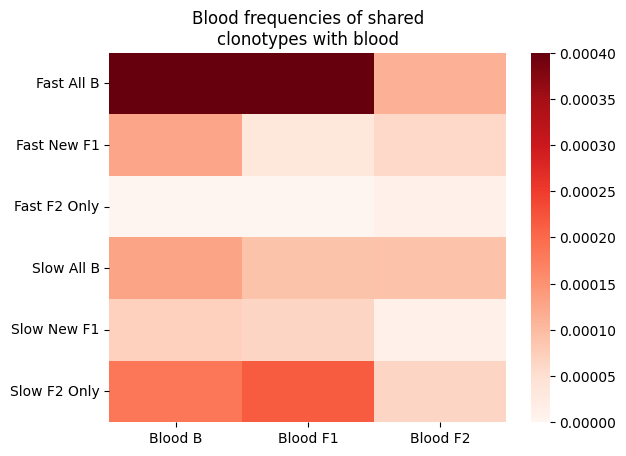

In [142]:
sns.heatmap(matrixplot_summ[['Blood B','Blood F1','Blood F2']],cmap='Reds',vmax=0.0004)
plt.title('Blood frequencies of shared\nclonotypes with blood',
          )
plt.show()